# TensorFlow Hourly Rainfall Forecasting Using Sensor Data

This notebook trains an MLP rainfall forecasting model for ESP32 deployment from `historical_weather_data_hourly.csv` in the `weather_irrigation_hourly` folder. The model predicts the rainfall amount (in mm) directly from instantaneous weather sensor readings (temperature, humidity, vapour pressure deficit, soil temperature, soil moisture, shortwave radiation, and evapotranspiration).

## 1. Imports

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input

tf.keras.utils.set_random_seed(42)
np.random.seed(42)

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'historical_weather_data_hourly.csv'
KERAS_MODEL_PATH = BASE_DIR / 'hourly_rainfall_forecaster.keras'
TFLITE_MODEL_PATH = BASE_DIR / 'hourly_rainfall_forecaster.tflite'
CC_MODEL_PATH = BASE_DIR / 'hourly_rainfall_forecaster.cc'
H_MODEL_PATH = BASE_DIR / 'hourly_rainfall_forecaster.h'
METRICS_PATH = BASE_DIR / 'hourly_rainfall_metrics.json'
FEATURE_COLUMNS_PATH = BASE_DIR / 'hourly_feature_columns.json'
X_MEAN_PATH = BASE_DIR / 'hourly_X_mean.npy'
X_STD_PATH = BASE_DIR / 'hourly_X_std.npy'
Y_AMOUNT_MEAN_PATH = BASE_DIR / 'hourly_y_amount_mean.npy'
Y_AMOUNT_STD_PATH = BASE_DIR / 'hourly_y_amount_std.npy'
RAIN_THRESHOLD_MM = 0.1
C_ARRAY_NAME = 'hourly_rainfall_forecaster_tflite'

FEATURES = [
    'temperature_2m',
    'relative_humidity_2m',
    'vapour_pressure_deficit_kpa',
    'soil_temperature_0_to_7cm',
    'soil_moisture_0_to_7cm',
    'shortwave_radiation',
    'et0_fao_evapotranspiration_mm',
]


I0000 00:00:1780146537.608212  748865 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2. Load Data

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        'historical_weather_data_hourly.csv was not found. Run fetch_hourly_weather_data.py first.'
    )

df = pd.read_csv(DATA_PATH, parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)
df['precipitation_mm'] = df['precipitation_mm'].clip(lower=0)
df = df.dropna(subset=FEATURES + ['precipitation_mm'])
print(df[['time', 'precipitation_mm'] + FEATURES].head())
print(f'Loaded {len(df):,} hourly rows from {df.time.min()} to {df.time.max()}')


                 time  precipitation_mm  temperature_2m  relative_humidity_2m  \
0 2015-01-01 00:00:00               0.0            15.0                    70   
1 2015-01-01 01:00:00               0.0            14.0                    72   
2 2015-01-01 02:00:00               0.0            13.5                    73   
3 2015-01-01 03:00:00               0.0            13.2                    72   
4 2015-01-01 04:00:00               0.0            12.6                    74   

   vapour_pressure_deficit_kpa  soil_temperature_0_to_7cm  \
0                     0.511604                       14.3   
1                     0.447609                       13.8   
2                     0.417816                       13.4   
3                     0.424894                       12.9   
4                     0.379347                       12.5   

   soil_moisture_0_to_7cm  shortwave_radiation  et0_fao_evapotranspiration_mm  
0                   0.343                  0.0                    

## 3. Data Exploration

Before feeding the sensor metrics to our model, let's look at how precipitation correlates with our inputs. Understanding these distributions helps confirm whether our inputs carry a signal that the network can learn.

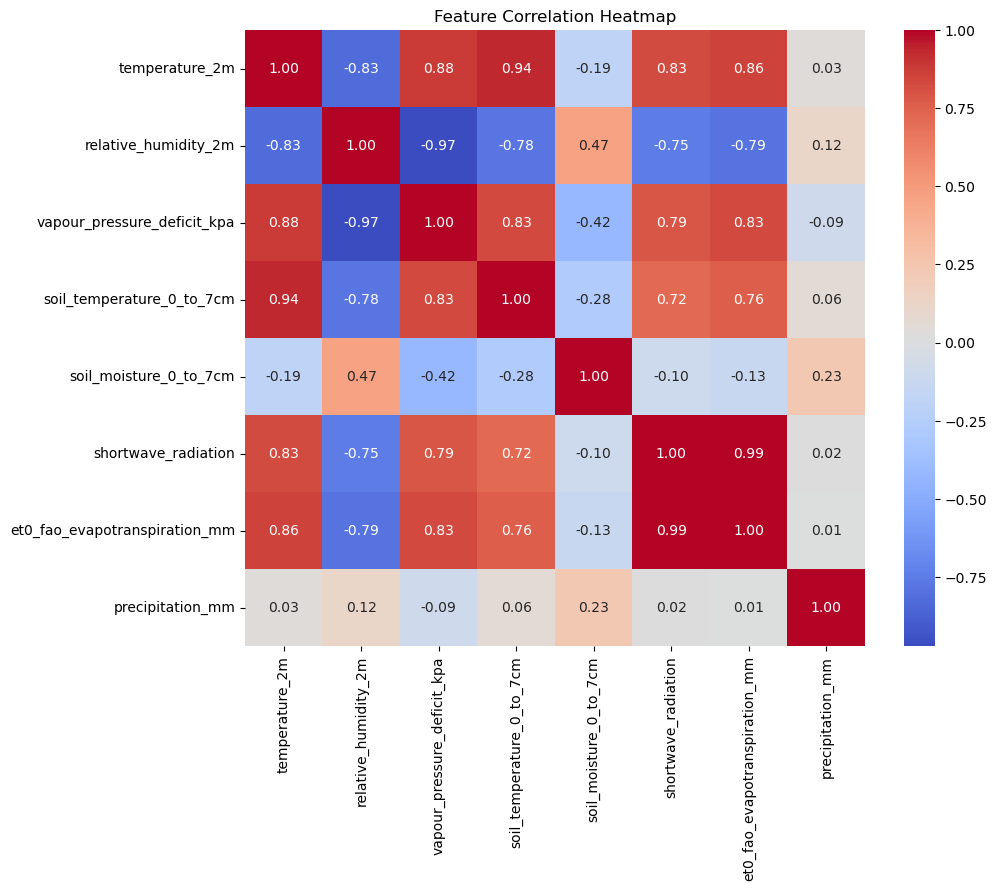

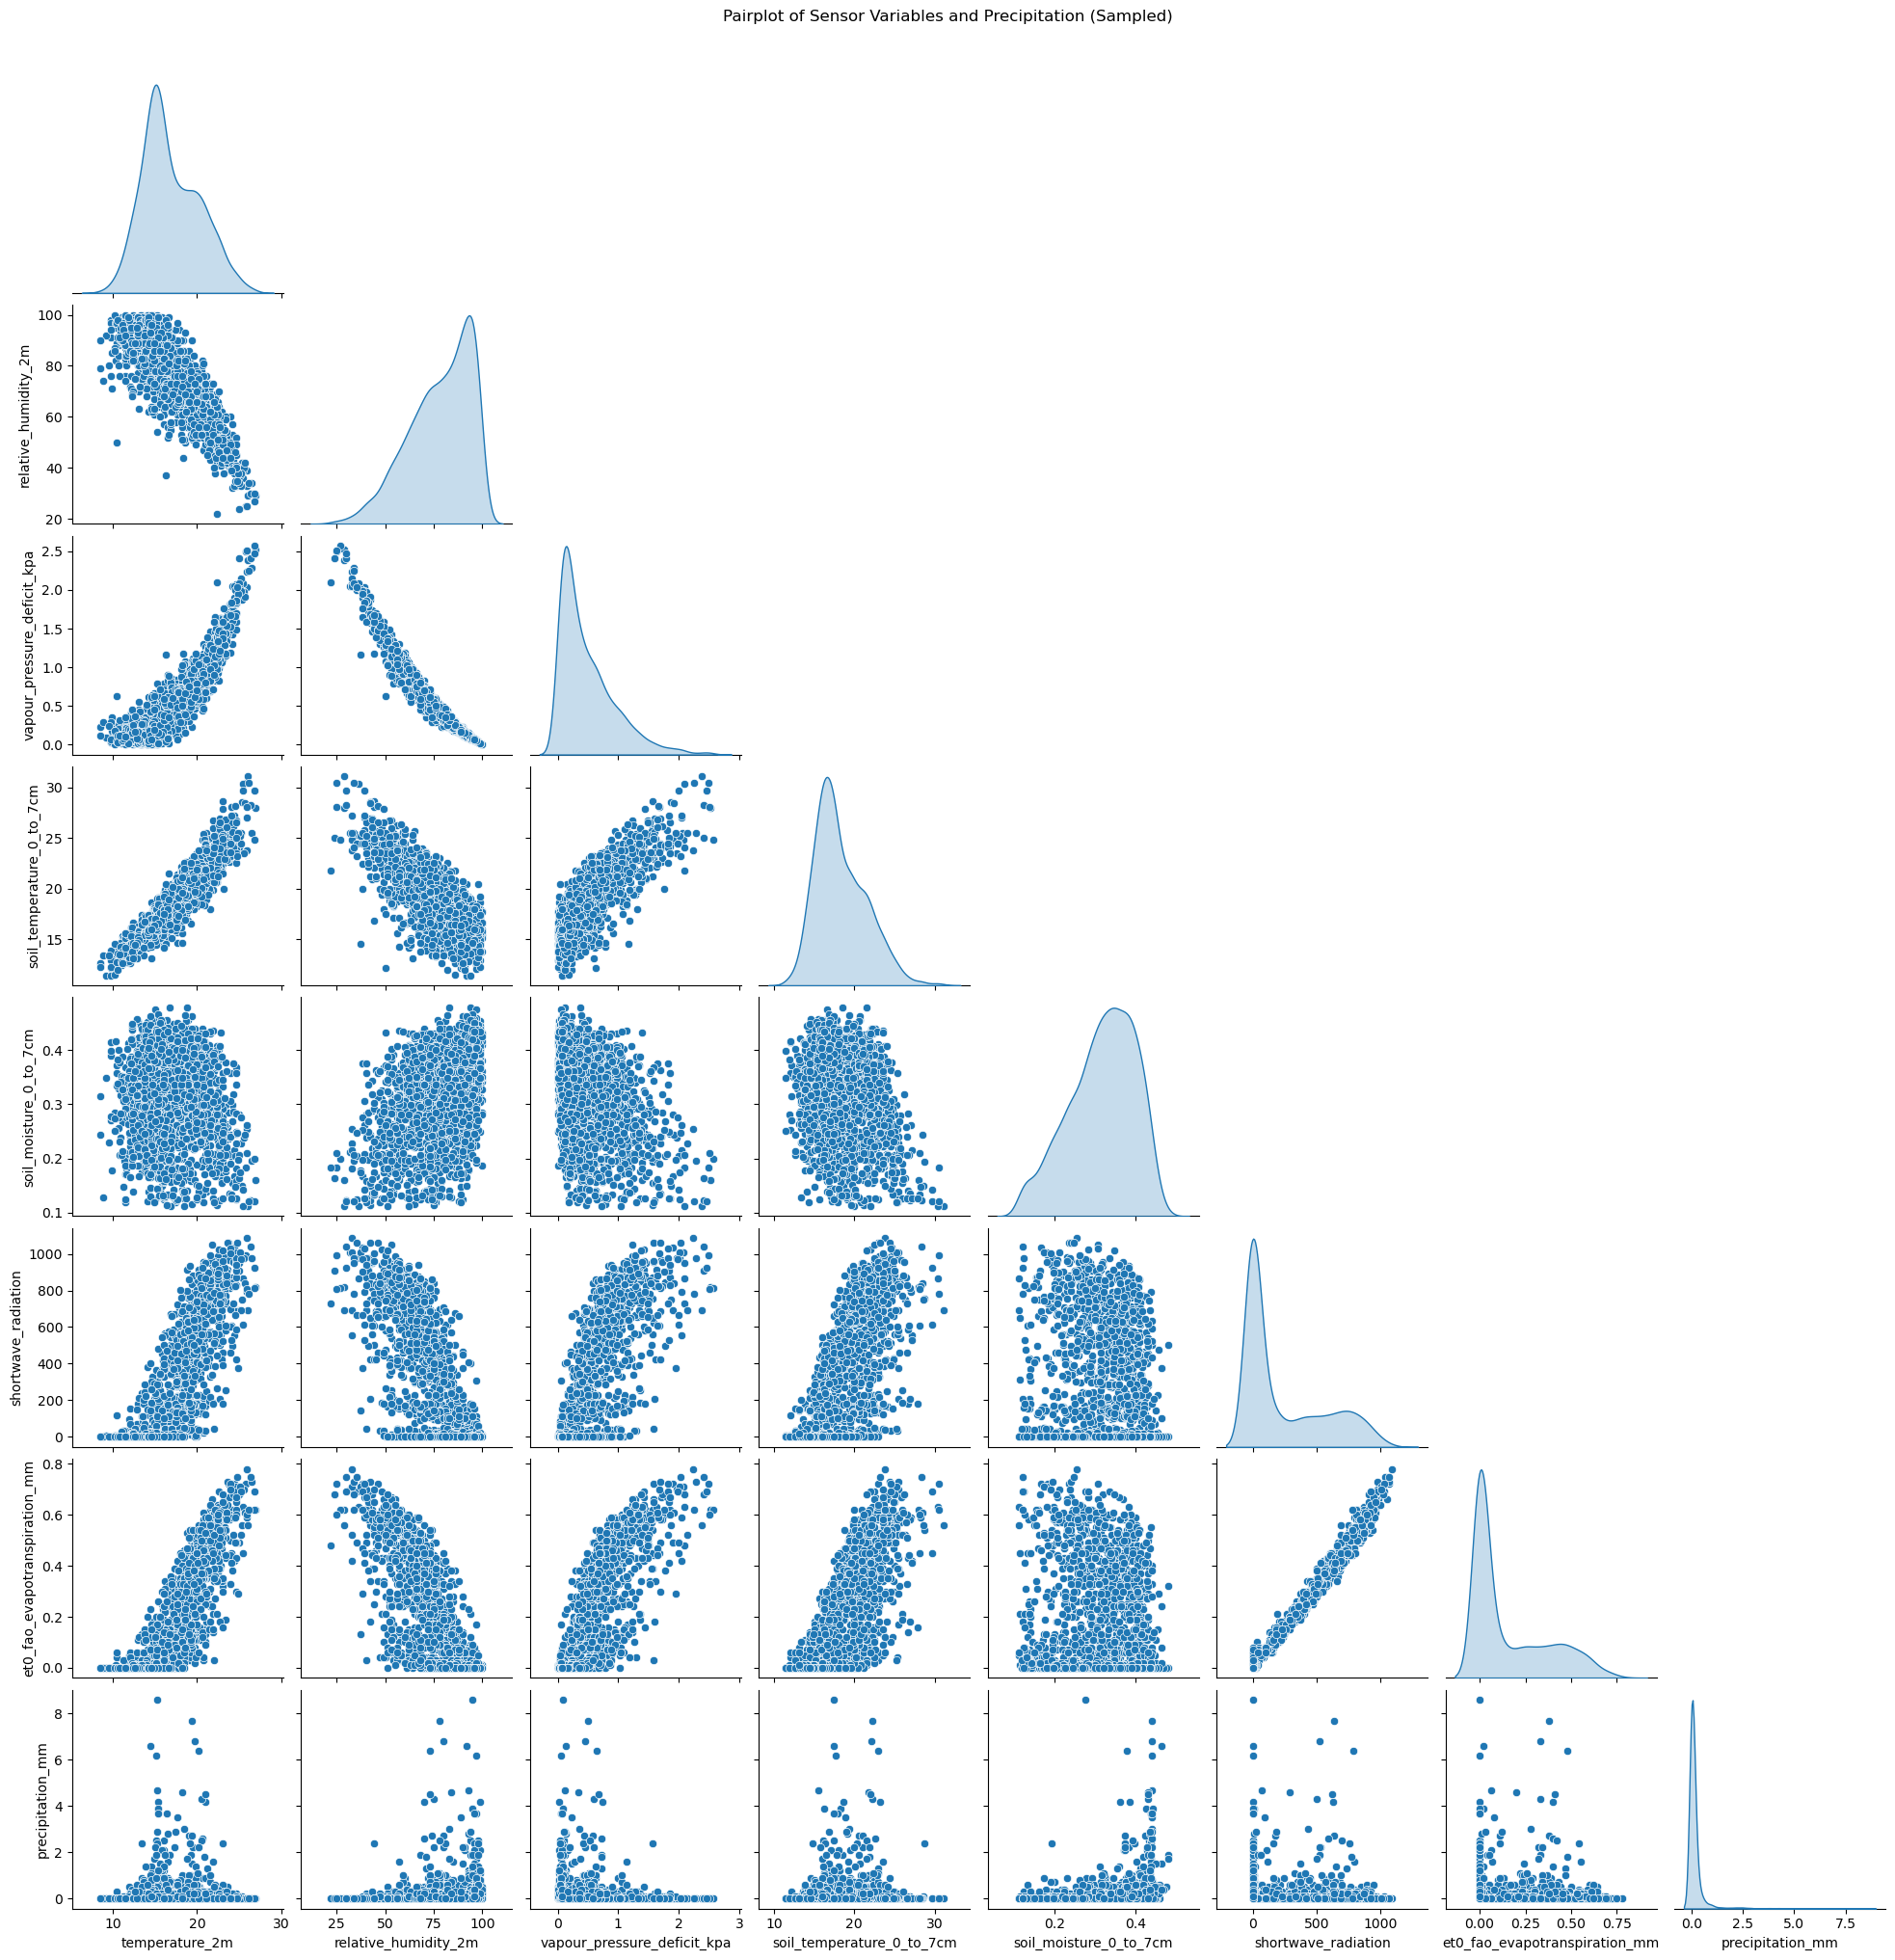

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[FEATURES + ['precipitation_mm']].corr(), annot=True, cmap='coolwarm', ax=ax, fmt='.2f')
ax.set_title('Feature Correlation Heatmap')
plt.show()

sns.pairplot(df[FEATURES + ['precipitation_mm']].sample(n=min(2000, len(df))), corner=True, diag_kind='kde')
plt.suptitle('Pairplot of Sensor Variables and Precipitation (Sampled)', y=1.02)
plt.show()


## 4. Time-Based Split And Scaling

The train-test split is chronological instead of random because forecasting must use the past to predict the future. A random split would leak future seasonal states into training and make evaluation look better than real deployment. Using the first 80% of the timeline for training and the latest 20% for testing gives a more realistic estimate of how the model behaves on unseen future months.

Scaling is fit on the training window only and then reused for the test window. That keeps the preprocessing aligned with deployment, where future data statistics are not known in advance. The target precipitation amount is log-scaled before standardization because hourly rain is highly right-skewed: many dry hours and a small number of heavy-rain events. The log transform compresses those spikes so the regression loss is less dominated by a few extreme hours.

In [4]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[FEATURES].to_numpy(dtype=np.float32)
X_test = test_df[FEATURES].to_numpy(dtype=np.float32)
y_train_amount = train_df['precipitation_mm'].to_numpy(dtype=np.float32)
y_test_amount = test_df['precipitation_mm'].to_numpy(dtype=np.float32)

X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_std[X_std == 0] = 1e-6
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

y_train_amount_log = np.log1p(y_train_amount)
y_amount_mean = float(y_train_amount_log.mean())
y_amount_std = float(y_train_amount_log.std())
if y_amount_std == 0:
    y_amount_std = 1e-6
y_train_amount_scaled = ((y_train_amount_log - y_amount_mean) / y_amount_std).astype(np.float32)

np.save(X_MEAN_PATH, X_mean)
np.save(X_STD_PATH, X_std)
np.save(Y_AMOUNT_MEAN_PATH, np.array([y_amount_mean], dtype=np.float32))
np.save(Y_AMOUNT_STD_PATH, np.array([y_amount_std], dtype=np.float32))
FEATURE_COLUMNS_PATH.write_text(json.dumps(FEATURES, indent=2))
print(f'Train rows: {len(train_df):,}, test rows: {len(test_df):,}')
print(f'Feature count: {X_train_scaled.shape[1]}')


Train rows: 77,145, test rows: 19,287
Feature count: 7


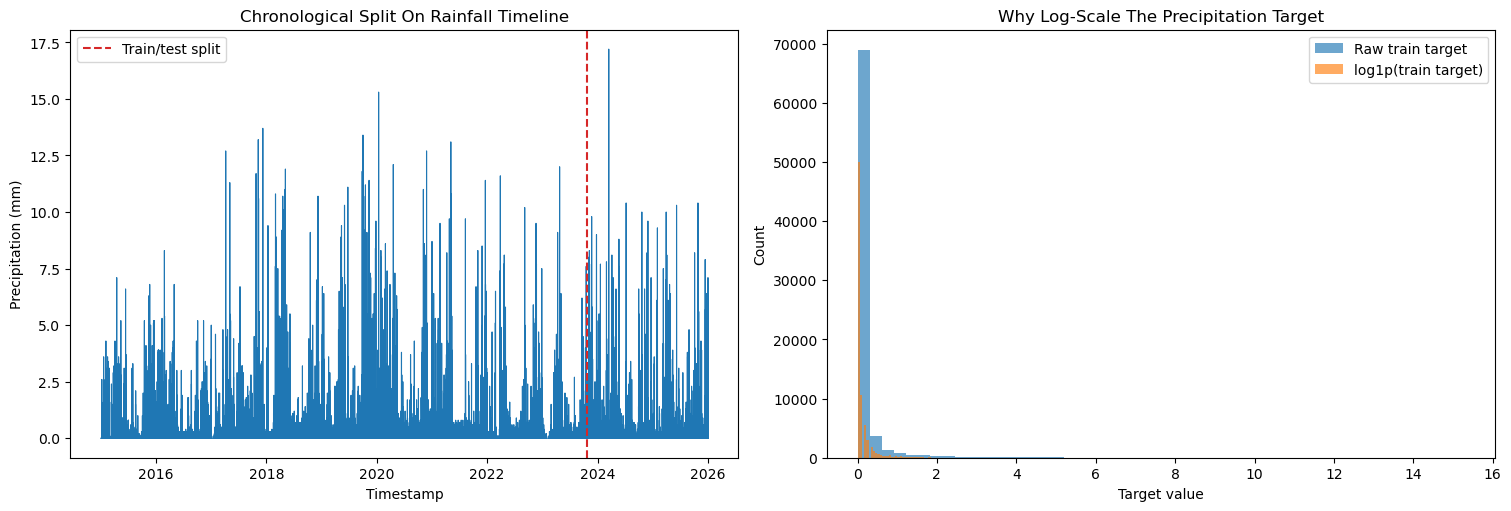

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

axes[0].plot(df['time'], df['precipitation_mm'], color='tab:blue', linewidth=0.8)
axes[0].axvline(df.loc[split_idx, 'time'], color='tab:red', linestyle='--', label='Train/test split')
axes[0].set_title('Chronological Split On Rainfall Timeline')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Precipitation (mm)')
axes[0].legend()

axes[1].hist(y_train_amount, bins=50, alpha=0.65, label='Raw train target', color='tab:blue')
axes[1].hist(np.log1p(y_train_amount), bins=50, alpha=0.65, label='log1p(train target)', color='tab:orange')
axes[1].set_title('Why Log-Scale The Precipitation Target')
axes[1].set_xlabel('Target value')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.show()



## 5. TensorFlow MLP Model

In [6]:
inputs = Input(shape=(X_train_scaled.shape[1],), name='sensor_features')
x = Dense(32, activation='relu')(inputs)
x = Dense(16, activation='relu')(x)
amount_output = Dense(1, name='amount_output')(x)

model = Model(inputs=inputs, outputs=amount_output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_features (InputLayer)    │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ amount_output (Dense)           │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train

In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
]

history = model.fit(
    X_train_scaled,
    y_train_amount_scaled,
    validation_split=0.15,
    epochs=40,
    batch_size=256,
    verbose=1,
    callbacks=callbacks,
)

print(f"Training stopped after {len(history.history['loss'])} epochs.")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")


Epoch 1/40



  1/257 ━━━━━━━━━━━━━━━━━━━━ 3:12 751ms/step - loss: 2.2643


 30/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5029    


 69/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2980


107/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2047

...


154/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6588


188/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6569


231/257 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6549


257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6430 - val_loss: 0.3565


Training stopped after 40 epochs.
Best val_loss: 0.3565


## 7. Evaluate

In [8]:
amount_pred_scaled = model.predict(X_test_scaled, verbose=0)
amount_pred_scaled = amount_pred_scaled.reshape(-1)
amount_pred = np.expm1((amount_pred_scaled * y_amount_std) + y_amount_mean).clip(min=0)
rainy_mask = y_test_amount >= RAIN_THRESHOLD_MM

def amount_metrics(y_true, y_pred):
    rainy_true = y_true[rainy_mask]
    rainy_pred = y_pred[rainy_mask]
    return {
        'mae_mm': float(mean_absolute_error(y_true, y_pred)),
        'rmse_mm': float(mean_squared_error(y_true, y_pred)**0.5),
        'r2': float(r2_score(y_true, y_pred)),
        'rainy_hours_count': int(rainy_mask.sum()),
        'rainy_mae_mm': float(mean_absolute_error(rainy_true, rainy_pred)) if len(rainy_true) > 0 else 0.0,
        'rainy_rmse_mm': float(mean_squared_error(rainy_true, rainy_pred)**0.5) if len(rainy_true) > 0 else 0.0,
    }

metrics = {
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'feature_columns': FEATURES,
    'amount_models': {
        'mlp_sensors': amount_metrics(y_test_amount, amount_pred),
    },
    'selected_amount_model': 'mlp_sensors',
}
print(json.dumps(metrics, indent=2))


{
  "train_rows": 77145,
  "test_rows": 19287,
  "feature_columns": [
    "temperature_2m",
    "relative_humidity_2m",
    "vapour_pressure_deficit_kpa",
    "soil_temperature_0_to_7cm",
    "soil_moisture_0_to_7cm",
    "shortwave_radiation",
    "et0_fao_evapotranspiration_mm"
  ],
  "amount_models": {
    "mlp_sensors": {
      "mae_mm": 0.13762885332107544,
      "rmse_mm": 0.49235289685933237,
      "r2": 0.25982630252838135,
      "rainy_hours_count": 5832,
      "rainy_mae_mm": 0.3322485387325287,
      "rainy_rmse_mm": 0.8849207592634926
    }
  },
  "selected_amount_model": "mlp_sensors"
}


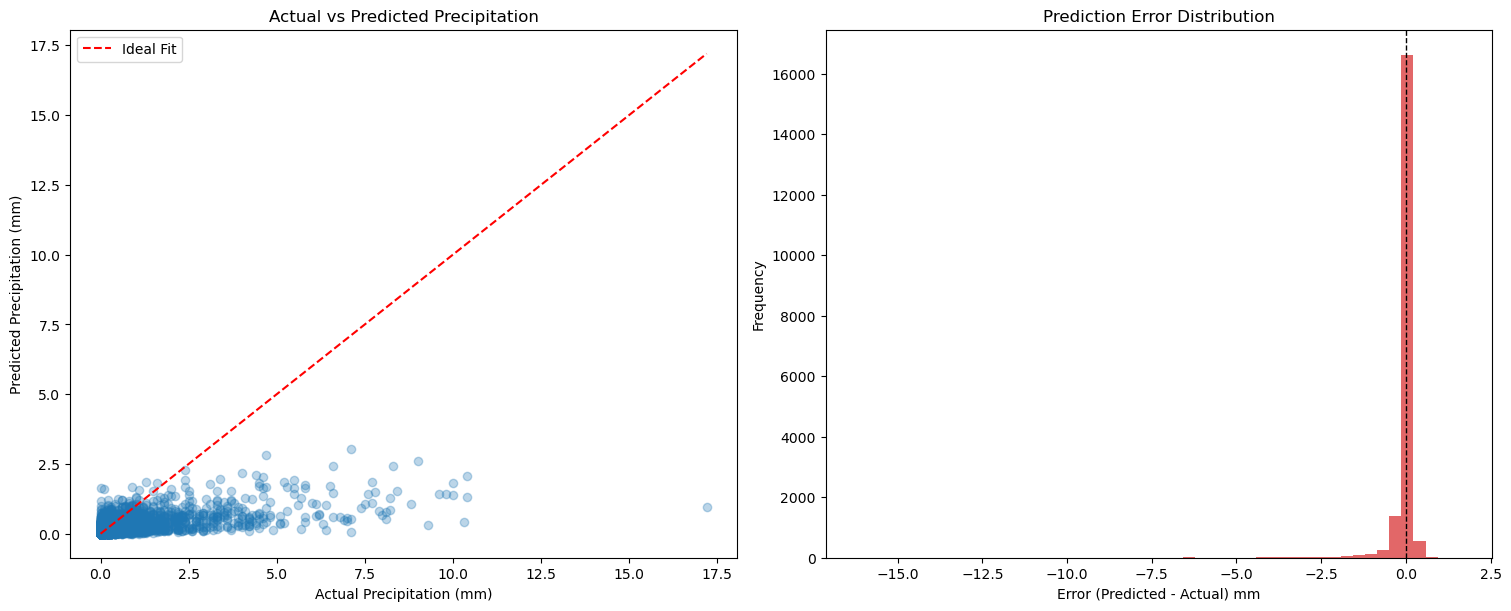

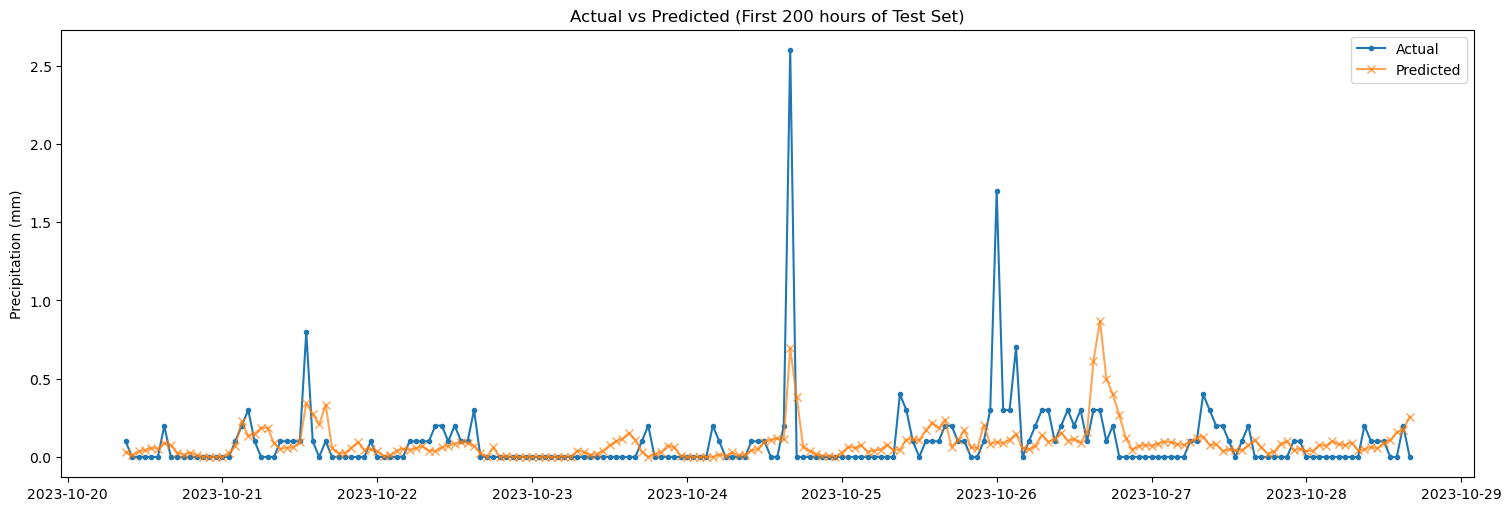

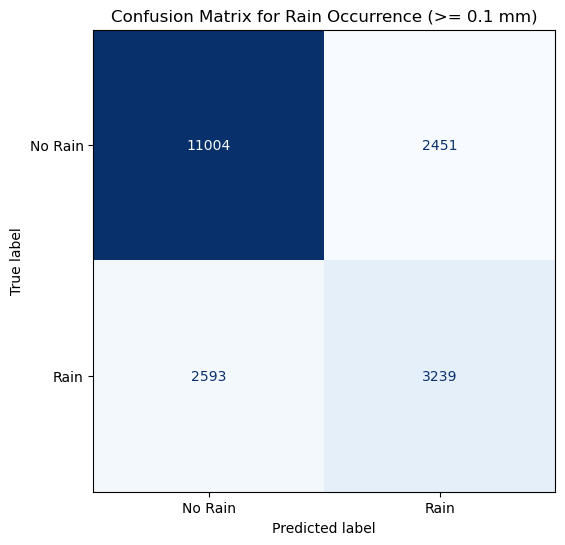

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

axes[0].scatter(y_test_amount, amount_pred, alpha=0.3, color='tab:blue')
axes[0].plot([0, y_test_amount.max()], [0, y_test_amount.max()], 'r--', label='Ideal Fit')
axes[0].set_title('Actual vs Predicted Precipitation')
axes[0].set_xlabel('Actual Precipitation (mm)')
axes[0].set_ylabel('Predicted Precipitation (mm)')
axes[0].legend()

error = amount_pred - y_test_amount
axes[1].hist(error, bins=50, color='tab:red', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='dashed', linewidth=1)
axes[1].set_title('Prediction Error Distribution')
axes[1].set_xlabel('Error (Predicted - Actual) mm')
axes[1].set_ylabel('Frequency')
plt.show()

fig, ax = plt.subplots(figsize=(15, 5), constrained_layout=True)
plot_slice = slice(0, 200)
time_slice = test_df['time'].iloc[plot_slice]
ax.plot(time_slice, y_test_amount[plot_slice], label='Actual', marker='.', color='tab:blue')
ax.plot(time_slice, amount_pred[plot_slice], label='Predicted', marker='x', color='tab:orange', alpha=0.7)
ax.set_title('Actual vs Predicted (First 200 hours of Test Set)')
ax.set_ylabel('Precipitation (mm)')
ax.legend()
plt.show()

cm = confusion_matrix(y_test_amount >= RAIN_THRESHOLD_MM, amount_pred >= RAIN_THRESHOLD_MM)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain', 'Rain'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix for Rain Occurrence (>= 0.1 mm)')
plt.show()


## 8. Export Keras, TFLite, And ESP32 Artifacts

In [10]:
def convert_tflite_to_c_array(tflite_path: Path, c_file_path: Path, h_file_path: Path, array_name: str):
    tflite_content = tflite_path.read_bytes()
    hex_array = [f'0x{byte:02x}' for byte in tflite_content]

    with c_file_path.open('w') as c_file:
        c_file.write(f'#include "{h_file_path.name}"\n\n')
        c_file.write(f'const unsigned char {array_name}[] = {{\n')
        for idx in range(0, len(hex_array), 12):
            c_file.write('  ' + ', '.join(hex_array[idx:idx + 12]) + ',\n')
        c_file.write('};\n\n')
        c_file.write(f'const int {array_name}_len = {len(tflite_content)};\n')

    with h_file_path.open('w') as h_file:
        guard = h_file_path.stem.upper() + '_H'
        h_file.write(f'#ifndef {guard}\n')
        h_file.write(f'#define {guard}\n\n')
        h_file.write(f'extern const unsigned char {array_name}[];\n')
        h_file.write(f'extern const int {array_name}_len;\n\n')
        h_file.write(f'#endif  // {guard}\n')

model.save(KERAS_MODEL_PATH)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
TFLITE_MODEL_PATH.write_bytes(tflite_model)
convert_tflite_to_c_array(TFLITE_MODEL_PATH, CC_MODEL_PATH, H_MODEL_PATH, C_ARRAY_NAME)
METRICS_PATH.write_text(json.dumps(metrics, indent=2))

print(f'Saved {KERAS_MODEL_PATH.name}')
print(f'Saved {TFLITE_MODEL_PATH.name} ({len(tflite_model)} bytes)')
print(f'Saved {CC_MODEL_PATH.name}')
print(f'Saved {H_MODEL_PATH.name}')
print(f'Saved {METRICS_PATH.name}')


INFO:tensorflow:Assets written to: /tmp/tmpydnhtycj/assets


INFO:tensorflow:Assets written to: /tmp/tmpydnhtycj/assets


Saved artifact at '/tmp/tmpydnhtycj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='sensor_features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140454577593648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140454595986400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140454661432544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140454661423184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140454661437104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140454661439264: TensorSpec(shape=(), dtype=tf.resource, name=None)


Saved hourly_rainfall_forecaster.keras
Saved hourly_rainfall_forecaster.tflite (5188 bytes)
Saved hourly_rainfall_forecaster.cc
Saved hourly_rainfall_forecaster.h
Saved hourly_rainfall_metrics.json


W0000 00:00:1780146563.480773  748865 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1780146563.480786  748865 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1780146563.481011  748865 reader.cc:83] Reading SavedModel from: /tmp/tmpydnhtycj
I0000 00:00:1780146563.481501  748865 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1780146563.481510  748865 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpydnhtycj
I0000 00:00:1780146563.484472  748865 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1780146563.484930  748865 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1780146563.503213  748865 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpydnhtycj
I0000 00:00:1780146563.510382  748865 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 29378 microseconds.
I0000 00:00:1780146563.519418  748865

## 9. Inference Helper

In [11]:
VPD_COLUMN = 'vapour_pressure_deficit_kpa'
RAW_SENSOR_FEATURES = [feature for feature in FEATURES if feature != VPD_COLUMN]

def calculate_vapour_pressure_deficit_kpa(temperature_c, relative_humidity_percent):
    temperature = np.asarray(temperature_c, dtype=np.float32)
    relative_humidity = np.clip(np.asarray(relative_humidity_percent, dtype=np.float32), 0.0, 100.0)
    saturation_vapour_pressure = 0.6108 * np.exp((17.27 * temperature) / (temperature + 237.3))
    return np.maximum(saturation_vapour_pressure * (1.0 - (relative_humidity / 100.0)), 0.0)

def prepare_sensor_readings(sensor_readings):
    readings = pd.DataFrame(sensor_readings)
    if all(isinstance(column, int) for column in readings.columns):
        if readings.shape[1] == len(FEATURES):
            readings.columns = FEATURES
        elif readings.shape[1] == len(RAW_SENSOR_FEATURES):
            readings.columns = RAW_SENSOR_FEATURES
        else:
            raise ValueError(f'Expected {len(FEATURES)} deployed features or {len(RAW_SENSOR_FEATURES)} raw sensor features, got {readings.shape[1]}.')

    if VPD_COLUMN not in readings.columns:
        readings[VPD_COLUMN] = calculate_vapour_pressure_deficit_kpa(
            readings['temperature_2m'],
            readings['relative_humidity_2m'],
        )

    missing = [feature for feature in FEATURES if feature not in readings.columns]
    if missing:
        raise ValueError(f'Missing required feature columns: {missing}')

    return readings[FEATURES].astype(np.float32)

def forecast_hourly_rainfall(sensor_readings):
    readings = prepare_sensor_readings(sensor_readings)
    X_future = readings.to_numpy(dtype=np.float32)
    X_future_scaled = (X_future - X_mean) / X_std
    amount_scaled = model.predict(X_future_scaled, verbose=0)
    amount_scaled = amount_scaled.reshape(-1)
    amount_log = (amount_scaled * y_amount_std) + y_amount_mean
    amount = np.expm1(np.maximum(amount_log, 0.0))
    return readings.assign(predicted_precipitation_mm=amount)[
        [VPD_COLUMN, 'predicted_precipitation_mm']
    ]

forecast_hourly_rainfall([
    {
        'temperature_2m': 25.0,
        'relative_humidity_2m': 60.0,
        'soil_temperature_0_to_7cm': 24.0,
        'soil_moisture_0_to_7cm': 0.290,
        'shortwave_radiation': 500.0,
        'et0_fao_evapotranspiration_mm': 0.5,
    },
    {
        'temperature_2m': 20.0,
        'relative_humidity_2m': 90.0,
        'soil_temperature_0_to_7cm': 19.0,
        'soil_moisture_0_to_7cm': 0.300,
        'shortwave_radiation': 100.0,
        'et0_fao_evapotranspiration_mm': 0.1,
    },
])


,vapour_pressure_deficit_kpa,predicted_precipitation_mm
0,1.267111,0.253329
1,0.233828,0.114729
